In [25]:
conda install opencv

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/sahil/miniconda3/envs/ds

  added / updated specs:
    - opencv


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    alsa-lib-1.2.15.3          |       h47b2149_0         570 KB
    attr-2.5.2                 |       h47b2149_0          66 KB
    aws-c-auth-0.10.1          |       h47b2149_0         118 KB
    aws-c-cal-0.9.13           |       h1b28b03_0          53 KB
    aws-c-common-0.12.6        |       h47b2149_0         233 KB
    aws-c-compression-0.3.2    |       h47b2149_0          18 KB
    aws-c-http-0.10.13         |  

In [27]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
dataset_path="../dataset"

In [12]:
classes = sorted(os.listdir(dataset_path))

print(classes)

['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']


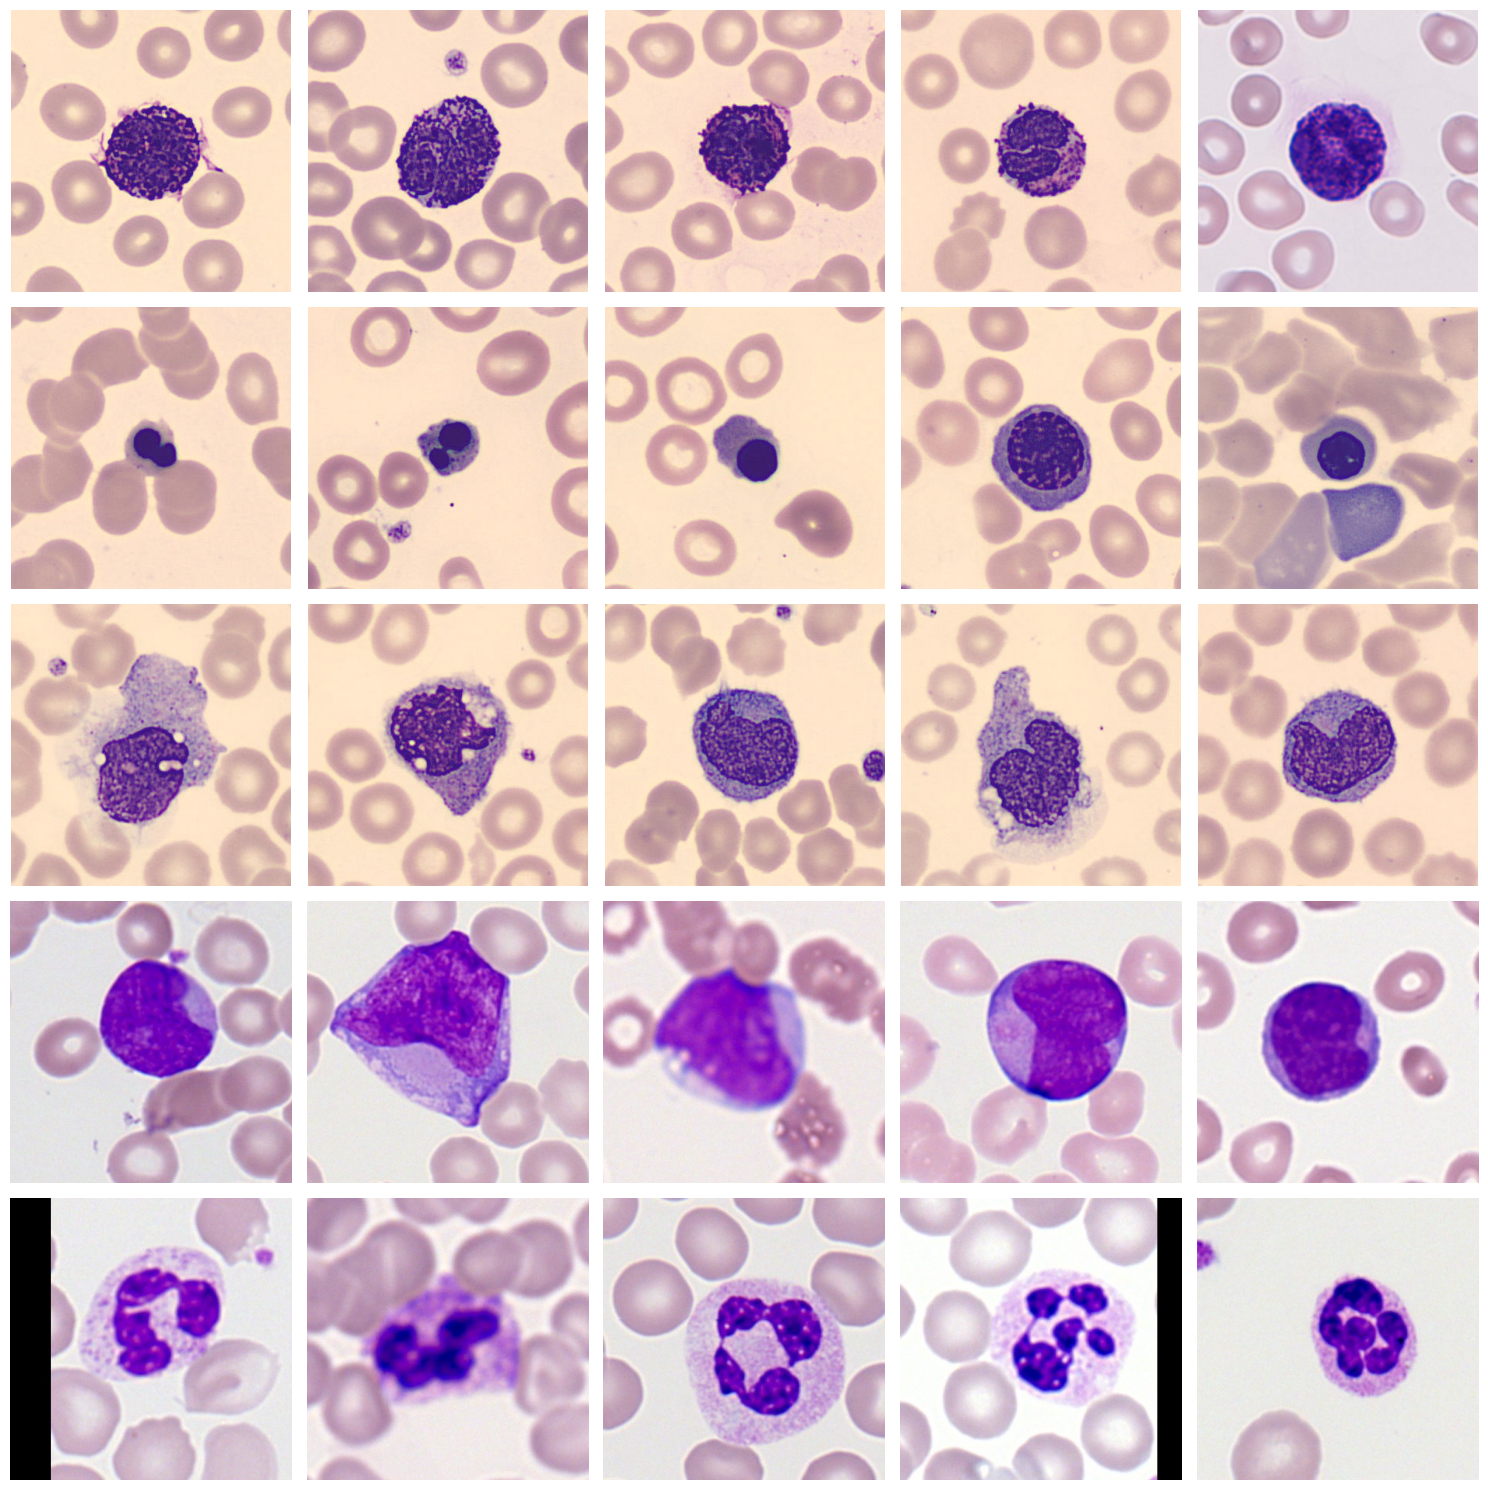

In [13]:
import random

fig, axes = plt.subplots(len(classes), 5, figsize=(15, 15))

for row, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)

    image_files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    images = random.sample(image_files, min(5, len(image_files)))

    for col, image in enumerate(images):

        img = Image.open(os.path.join(folder, image))

        axes[row][col].imshow(img)
        axes[row][col].axis("off")

        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
print(classes)
print(len(classes))

['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'notebooks', 'seg_neutrophil']
6


In [14]:
from collections import Counter

size_counter = Counter()

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for image in os.listdir(folder):

        if image.lower().endswith((".jpg", ".jpeg", ".png")):

            img = Image.open(os.path.join(folder, image))

            size_counter[img.size] += 1

size_counter

Counter({(360, 363): 2887, (400, 400): 2000, (366, 369): 80, (360, 360): 33})

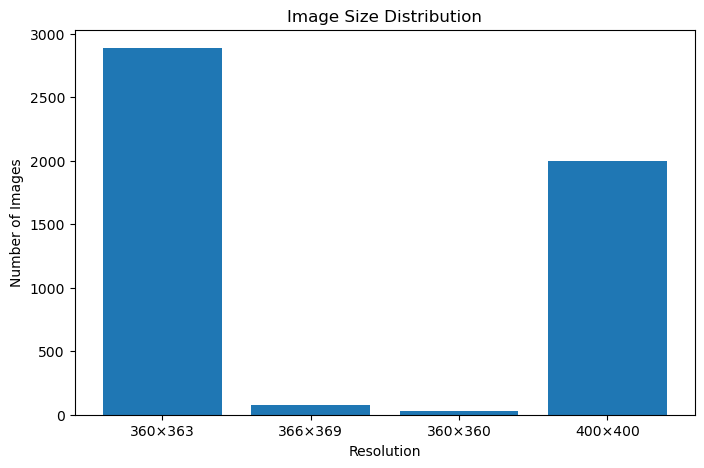

In [15]:
sizes = list(size_counter.keys())
counts = list(size_counter.values())

labels = [f"{w}×{h}" for w, h in sizes]

plt.figure(figsize=(8,5))

plt.bar(labels, counts)

plt.title("Image Size Distribution")

plt.xlabel("Resolution")

plt.ylabel("Number of Images")

plt.show()

In [18]:
sample_path = os.path.join(
    dataset_path,
    classes[0],
    os.listdir(os.path.join(dataset_path, classes[0]))[0]
)

img = np.array(Image.open(sample_path))

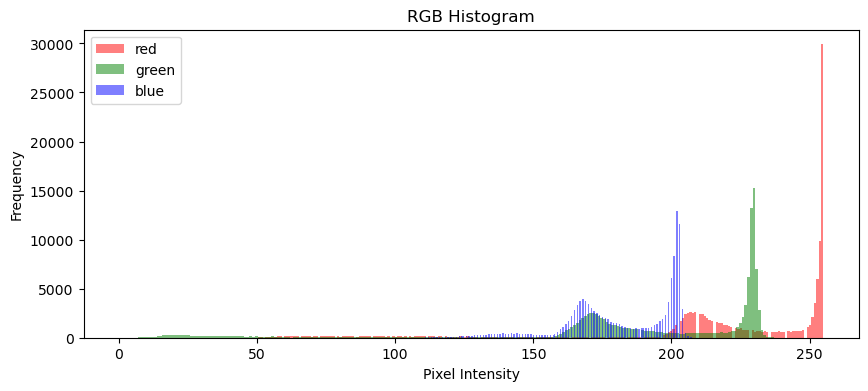

In [19]:
plt.figure(figsize=(10,4))

colors = ("red", "green", "blue")

for i, color in enumerate(colors):
    plt.hist(
        img[:, :, i].ravel(),
        bins=256,
        color=color,
        alpha=0.5,
        label=color
    )

plt.legend()
plt.title("RGB Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

In [20]:
import numpy as np
from PIL import Image

mean = np.zeros(3)
std = np.zeros(3)
total_pixels = 0

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            img = Image.open(os.path.join(folder, file))
            img = img.resize((224, 224))
            img = np.array(img) / 255.0

            pixels = img.reshape(-1, 3)

            mean += pixels.sum(axis=0)
            total_pixels += pixels.shape[0]

mean /= total_pixels

print("Dataset Mean:", mean)

Dataset Mean: [0.84602024 0.73239785 0.76647066]


In [21]:
std = np.zeros(3)

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            img = Image.open(os.path.join(folder, file))
            img = img.resize((224, 224))
            img = np.array(img) / 255.0

            pixels = img.reshape(-1, 3)

            std += ((pixels - mean) ** 2).sum(axis=0)

std = np.sqrt(std / total_pixels)

print("Dataset Std:", std)

Dataset Std: [0.17339585 0.22708519 0.10567995]


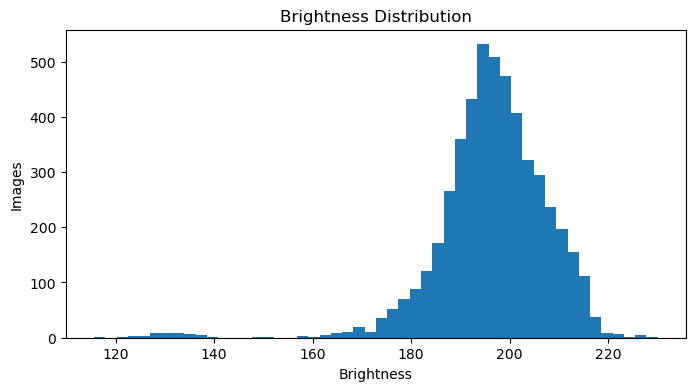

In [22]:
brightness = []

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        if file.lower().endswith((".jpg",".jpeg",".png")):

            img = Image.open(os.path.join(folder,file))
            gray = np.array(img.convert("L"))

            brightness.append(gray.mean())

plt.figure(figsize=(8,4))
plt.hist(brightness, bins=50)
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Images")
plt.show()

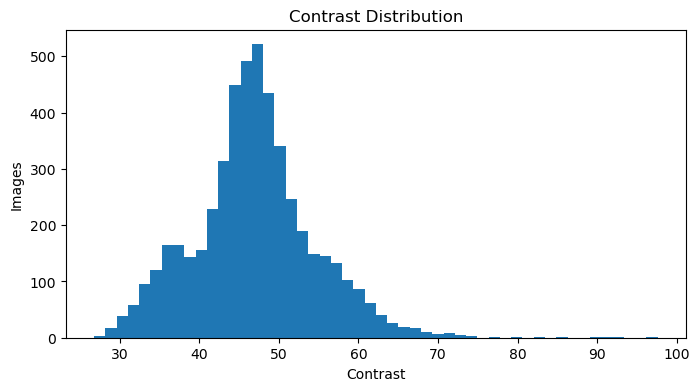

In [23]:
contrast = []

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        if file.lower().endswith((".jpg",".jpeg",".png")):

            img = Image.open(os.path.join(folder,file))
            gray = np.array(img.convert("L"))

            contrast.append(gray.std())

plt.figure(figsize=(8,4))
plt.hist(contrast, bins=50)

plt.title("Contrast Distribution")
plt.xlabel("Contrast")
plt.ylabel("Images")

plt.show()

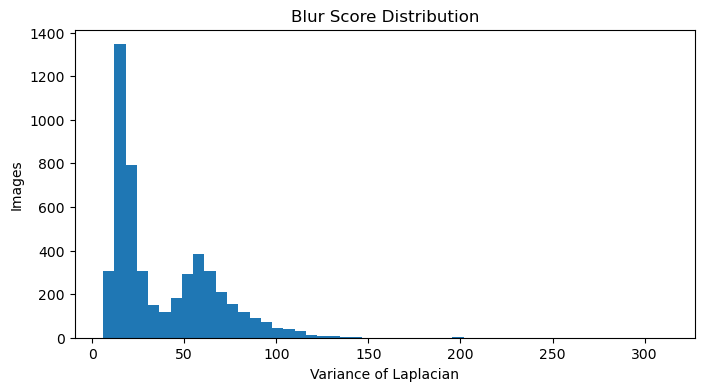

In [26]:
import cv2

blur = []

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        if file.lower().endswith((".jpg",".jpeg",".png")):

            img = cv2.imread(os.path.join(folder,file))

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            score = cv2.Laplacian(gray, cv2.CV_64F).var()

            blur.append(score)

plt.figure(figsize=(8,4))

plt.hist(blur, bins=50)

plt.title("Blur Score Distribution")

plt.xlabel("Variance of Laplacian")

plt.ylabel("Images")

plt.show()